<!--- sf-header --->
<table align="left">
<tr>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fstatmike%2Fscale-forecasting%2Fmain%2Fnotebooks%2Fmodel_playground.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Colab Enterprise logo">
      <br>Run in<br>Colab Enterprise
    </a>
  </td>
</tr>
</table>
<br clear="left"/>

> **Run in Colab Enterprise:** click the badge to import this notebook, pick a runtime, and
> **Run all**. The Terraform-deployed templates already carry the `SF_*` run identity in their env,
> so there's no environment cell to fill in. Runs on the **`sf-main`** runtime template (Python 3.11) — or fully locally with just ADC + a clone; the playground needs no cloud at all. See
> [`docs/notebook_runtimes.md`](https://github.com/statmike/scale-forecasting/blob/main/docs/notebook_runtimes.md)
> for the per-notebook template mapping and the headless acceptance harness.


# Model Playground

The first-class local dev loop for **scale-forecasting**: pick any registered model, run it on a small sample dataset, and see the forecast + metric panel — all offline, no GCP.

It runs the **same code path** as a production run (`playground` → `worker.run_cell`), so what you see here is what runs at scale. To add your own model, copy `docs/model_template.py` into `src/scale_forecasting/models/` and re-run the cells — it appears in the model list automatically.

Read order if you're new: `README.md` → `config.py` → `worker.py` → one file under `models/`.

## 1. Get the code (cloud runtimes only)

On a cloud notebook (Colab Enterprise, Vertex Workbench) this cell clones or updates the repo so you're always on the latest `src/`. **Skip it when running inside a local clone** — it's a no-op guarded on the repo already being importable.

In [1]:
# Cloud bootstrap: clone + install the LOCKED dependency set (uv.lock) so
# `import scale_forecasting` resolves against the exact versions every other surface runs.
# Uses uv (Colab ships it; we install it if missing) to install the frozen lock into a PRIVATE
# prefix, then puts that prefix + src/ first on sys.path. Harmless locally — if it already imports,
# no-op.
import importlib.util
import os
import shutil
import subprocess
import sys

REPO_URL = os.environ.get("SF_REPO_URL", "https://github.com/statmike/scale-forecasting.git")
REPO_DIR = os.environ.get("SF_REPO_DIR", "scale-forecasting")

EXTRAS = []  # this notebook needs only the core

if importlib.util.find_spec("scale_forecasting") is None:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    else:
        subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only"], check=True)
    uv = shutil.which("uv")
    if uv is None:  # Colab Enterprise ships uv; install it if this runtime doesn't
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)
        uv = shutil.which("uv") or "uv"
    # Resolve the checked-in lock to a requirements file (no re-resolve), then install EXACTLY
    # that set into this kernel — the same versions the container + packed-venv are built from.
    reqs = os.path.abspath(os.path.join(REPO_DIR, "colab-requirements.txt"))
    extra_flags = [f for e in EXTRAS for f in ("--extra", e)]
    subprocess.run(
        [uv, "export", "--frozen", "--no-emit-project", "--no-hashes", "--no-dev", *extra_flags,
         "-o", reqs],
        cwd=REPO_DIR, check=True,
    )
    # Install the LOCKED set into a PRIVATE directory (not the runtime's system site-packages),
    # then put it FIRST on sys.path. Managed images (Colab Enterprise, Vertex) ship numpy 2.x that
    # can't be cleanly downgraded in place: uv skips the version-satisfied packages it can't fully
    # uninstall, so numpy-2 .so files end up beside numpy-1 python and `import numpy` dies with
    # "dtype size changed, Expected 96 ... got 88". Installing to a separate prefix and SHADOWING the
    # base packages (never touching them) gives this kernel a clean, self-consistent numpy 1.26.4 —
    # the same set every other surface runs — with zero risk of a mixed install.
    target = os.path.abspath(os.path.join(REPO_DIR, ".colab-deps"))
    subprocess.run(
        [uv, "pip", "install", "--python", sys.executable, "--target", target, "-r", reqs],
        check=True,
    )
    # src/ carries our package; `target` carries its locked deps. Both go ahead of the base image's
    # site-packages so imports resolve to the versions we installed, not the runtime's.
    sys.path.insert(0, target)
    sys.path.insert(0, os.path.join(REPO_DIR, "src"))
    print("installed scale_forecasting from", REPO_DIR)
else:
    print("scale_forecasting already importable — skipping bootstrap")

installed scale_forecasting from scale-forecasting


## 2. Discover the models

`available_models()` reads the factory registry, so every model file that ends with `register(...)` shows up here — including one you just added.

`model_catalog()` is the full picture: **every** registered model — the Python models *and* the two BigQuery-native ones (`arima_plus`, `timesfm`) — with the runtimes each can run on. The Python models run the *identical* cell code on **local / spark / ray** (and the one deep-learning model, `neuralprophet`, also uses the Ray **GPU** pool); the native models run only in **BigQuery** as SQL. The flags are derived from each model's class metadata, so the table stays honest as the suite grows. This playground runs the **local** column offline; see notebook **02** for the BigQuery-native track and **04** for Ray.

In [2]:
from scale_forecasting.playground import (
    available_models,
    model_catalog,
    run_model,
    sample_data,
    summarize,
)

MODELS = available_models()  # the Python models this playground runs locally
print("models runnable locally in this playground:")
for m in MODELS:
    print(" ", m)

# The whole suite, with where each model can run (local / spark / ray / gpu / bigquery).
print("\nfull model catalog:")
model_catalog()

models runnable locally in this playground:
  autoets
  croston
  holtwinters
  lightgbm
  naive_drift
  naive_mean
  naive_moving_average
  naive_seasonal
  neuralprophet
  prophet
  regression_lags
  sarimax
  stl_bagging
  theta
  ucm
  xgboost

full model catalog:


,model,family,runtime,local,spark,ray,gpu,bigquery,exog
0,arima_plus,native,bigquery,False,False,False,False,True,False
1,timesfm,native,bigquery,False,False,False,False,True,False
2,neuralprophet,deep_learning,python,True,True,True,True,False,False
3,lightgbm,ml,python,True,True,True,False,False,True
4,regression_lags,ml,python,True,True,True,False,False,True
5,xgboost,ml,python,True,True,True,False,False,True
6,autoets,statistical,python,True,True,True,False,False,False
7,croston,statistical,python,True,True,True,False,False,False
8,holtwinters,statistical,python,True,True,True,False,False,False
9,naive_drift,statistical,python,True,True,True,False,False,False


## 3. Look at the sample data

A small, deterministic panel from the real generator (same code as the shipped 100k dataset). Five archetypes make different models win — pick a `ts_id` to focus on.

In [3]:
data = sample_data(n_series=5, history=730, freq="D")
print(data.groupby("ts_id")["archetype"].first())
data.head()

ts_id
s_000000    smooth_seasonal
s_000001       intermittent
s_000002           trending
s_000003        promo_spiky
s_000004              noisy
Name: archetype, dtype: object


,ts_id,archetype,ds,y
0,s_000000,smooth_seasonal,2021-01-01,207.801
1,s_000000,smooth_seasonal,2021-01-02,191.939
2,s_000000,smooth_seasonal,2021-01-03,207.561
3,s_000000,smooth_seasonal,2021-01-04,186.971
4,s_000000,smooth_seasonal,2021-01-05,141.360


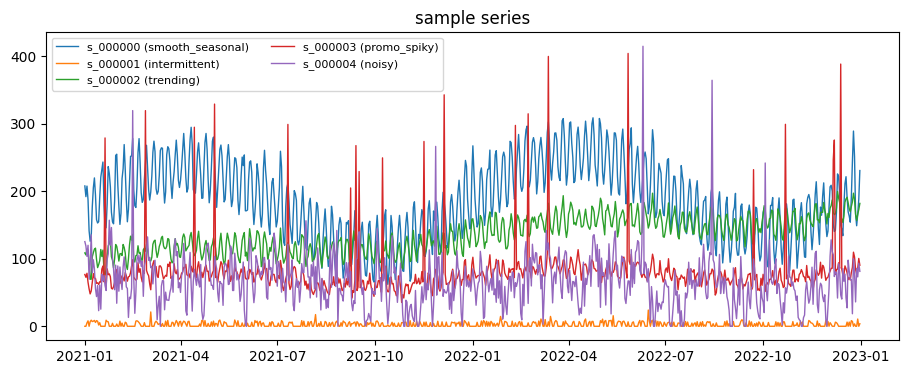

In [4]:
# Plot the history of each sample series.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4))
for ts_id, g in data.groupby("ts_id"):
    ax.plot(g["ds"], g["y"], label=f"{ts_id} ({g['archetype'].iloc[0]})", lw=1)
ax.legend(fontsize=8, ncol=2)
ax.set_title("sample series")
plt.show()

## 4. Run a model

Change `MODEL` and `TS_ID` and re-run. `backtest=True` scores the model (a 3-fold time-series CV) so the metric panel is populated; with it off, metrics are NaN by design (a single full-fit run doesn't score itself). This calls the real `worker.run_cell` — a model failure comes back as an *error cell*, it never raises.

In [5]:
MODEL = "theta"  # any name from section 2
TS_ID = "s_000000"  # any series from section 3
HORIZON = 28

run = run_model(MODEL, data=data, ts_id=TS_ID, horizon=HORIZON, backtest=True)
print(summarize(run))

/mnt/executor/scratch/scale-forecasting/.colab-deps/statsmodels/tsa/forecasting/theta.py:44: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  return DeterministicTerm._extend_index(index, steps)


/mnt/executor/scratch/scale-forecasting/.colab-deps/statsmodels/tsa/forecasting/theta.py:44: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  return DeterministicTerm._extend_index(index, steps)


/mnt/executor/scratch/scale-forecasting/.colab-deps/statsmodels/tsa/forecasting/theta.py:44: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  return DeterministicTerm._extend_index(index, steps)


/mnt/executor/scratch/scale-forecasting/.colab-deps/statsmodels/tsa/forecasting/theta.py:44: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  return DeterministicTerm._extend_index(index, steps)


model      : theta
series     : s_000000  (730 obs)
engine     : spark
status     : ok
forecast   : 28 steps
horizon    : 2023-01-01 → 2023-01-28
metrics    : mae=18.203, rmse=22.788, mse=568.143, mape=0.107, smape=0.115, wape=0.111, mase=0.698, rmsse=0.743, bias=-15.515, coverage=1.000, pinball=15.327, mase_seasonal=1.496, maape=0.106, interval_score=306.545, interval_width=306.545


## 5. The prediction frame + metric panel

Every model returns the identical canonical frame (`ds, yhat, yhat_lower, yhat_upper, quantiles`) in original units, with ordered bounds.

In [6]:
import pandas as pd

print("metric panel (backtest):")
print(pd.Series(run.result.metrics).round(4))
print("\nforecast frame (head):")
run.result.predictions.head()

metric panel (backtest):
mae                18.2030
rmse               22.7884
mse               568.1426
mape                0.1069
smape               0.1151
wape                0.1111
mase                0.6977
rmsse               0.7426
bias              -15.5146
coverage            1.0000
pinball            15.3273
mase_seasonal       1.4961
maape               0.1058
interval_score    306.5453
interval_width    306.5453
dtype: float64

forecast frame (head):


,ds,yhat,yhat_raw,yhat_adjusted,yhat_lower,yhat_upper,quantiles
0,2023-01-01,251.079185,245.606666,251.079185,236.221230,284.236954,"{""0.1"": 236.221229520552, ""0.5"": 251.079185302..."
1,2023-01-02,228.946011,223.473492,228.946011,214.088056,262.103780,"{""0.1"": 214.08805564569036, ""0.5"": 228.9460114..."
2,2023-01-03,176.784958,173.736921,176.784958,164.351485,212.367210,"{""0.1"": 164.35148471904435, ""0.5"": 176.7849575..."
3,2023-01-04,149.030920,148.995958,149.030920,139.610522,194.646113,"{""0.1"": 139.61052200110277, ""0.5"": 149.0309203..."
4,2023-01-05,159.221052,159.186090,159.221052,149.800654,204.836245,"{""0.1"": 149.8006540610118, ""0.5"": 159.22105242..."


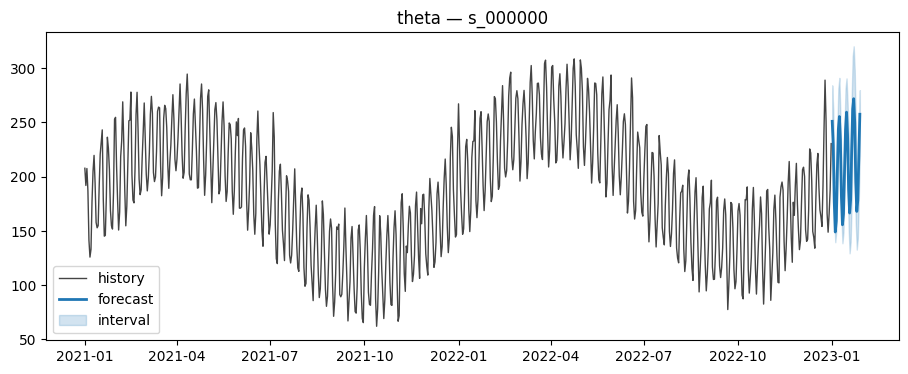

In [7]:
# Plot history + forecast with the prediction interval.
hist = run.series
pred = run.result.predictions

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hist["ds"], hist["y"], label="history", lw=1, color="#444")
ax.plot(pred["ds"], pred["yhat"], label="forecast", lw=2, color="#1f77b4")
ax.fill_between(
    pred["ds"],
    pred["yhat_lower"],
    pred["yhat_upper"],
    alpha=0.2,
    color="#1f77b4",
    label="interval",
)
ax.legend()
ax.set_title(f"{MODEL} — {TS_ID}")
plt.show()

## 6. Bake-off — many models + ensembles, head-to-head

Sections 4–5 inspect **one** model. `bakeoff()` runs **several** on the same series with backtesting on, then builds **two ensembles** on top — and it does all of it through the *actual framework functions a 100k run uses*, just in-memory instead of on BigQuery/Spark:

- each base model runs through `worker.run_cell` (the production cell);
- a **calculated** ensemble (`inverse_error`) blends the base forecasts via `ensembler.combine_calculated`, weighting each model by `1/WAPE` from its backtest;
- a **learned** ensemble (`nnls`) trains a meta-learner on the base **backtest OOF** via `ensembler.fit_learned`, then applies the weights via `ensemble_run._apply_weights`;
- every ensemble is scored on the OOF window with `ensembler.combine_oof` + `metrics.compute_metrics` — the identical path `ensemble_run.run_ensembles` uses at scale, minus the GCP I/O.

So the leaderboard below is what a scaled run would produce for this series — the ensembles routinely edge out the best single model. This is the whole pipeline (fan-out → backtest → ensemble → score → rank) on your laptop, no cloud.

In [8]:
from scale_forecasting.playground import bakeoff

# Run several models on ONE series + two ensembles (calculated + learned), all via the framework.
bo = bakeoff(data=data, ts_id=TS_ID, horizon=HORIZON, n_folds=2)

# Leaderboard: base models and ensemble_* rows, ranked by WAPE (lower is better).
cols = ["model", "kind", "status", "wape", "mae", "rmse", "mape", "smape"]
bo.leaderboard[cols].round(4)

/mnt/executor/scratch/scale-forecasting/.colab-deps/statsmodels/tsa/forecasting/theta.py:44: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  return DeterministicTerm._extend_index(index, steps)


/mnt/executor/scratch/scale-forecasting/.colab-deps/statsmodels/tsa/forecasting/theta.py:44: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  return DeterministicTerm._extend_index(index, steps)


/mnt/executor/scratch/scale-forecasting/.colab-deps/statsmodels/tsa/forecasting/theta.py:44: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  return DeterministicTerm._extend_index(index, steps)


/mnt/executor/scratch/scale-forecasting/.colab-deps/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/mnt/executor/scratch/scale-forecasting/.colab-deps/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/mnt/executor/scratch/scale-forecasting/.colab-deps/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


,model,kind,status,wape,mae,rmse,mape,smape
0,xgboost,base,ok,0.0917,16.0380,21.2164,0.0898,0.0922
1,ensemble_inverse_error,ensemble,ok,0.0967,16.5117,21.5605,0.0937,0.1007
2,holtwinters,base,ok,0.1055,18.0321,21.3551,0.1055,0.1125
3,ensemble_nnls,ensemble,ok,0.1062,18.1609,23.7835,0.1009,0.1094
4,stl_bagging,base,ok,0.1269,21.7522,27.2861,0.1260,0.1400
5,theta,base,ok,0.1280,21.9287,27.2388,0.1222,0.1342


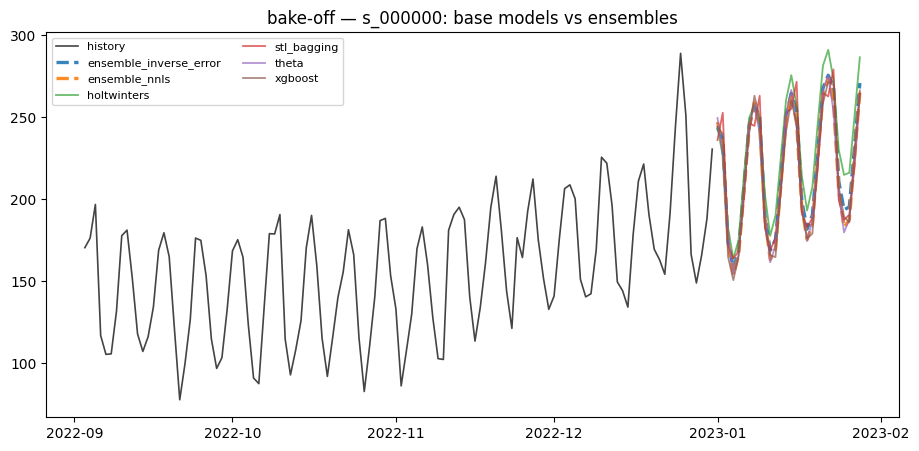

In [9]:
# Overlay every model's forecast on the recent history — ensembles drawn heavier/dashed.
recent = bo.series.tail(120)
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(recent["ds"], recent["y"], label="history", lw=1.2, color="#444")
for model, g in bo.predictions.sort_values("forecast_date").groupby("model"):
    is_ens = g["kind"].iloc[0] == "ensemble"
    ax.plot(
        g["forecast_date"],
        g["yhat"],
        label=model,
        lw=2.4 if is_ens else 1.3,
        ls="--" if is_ens else "-",
        alpha=0.9 if is_ens else 0.7,
    )
ax.legend(fontsize=8, ncol=2)
ax.set_title(f"bake-off — {TS_ID}: base models vs ensembles")
plt.show()

## 7. Add your own model

1. Copy `docs/model_template.py` → `src/scale_forecasting/models/my_model.py`.
2. Rename the class, set `name = "my_model"`, fill in `fit` / `predict`.
3. Add `my_model,` to the import block in `src/scale_forecasting/models/__init__.py`.
4. Restart the kernel and re-run section 2 — `my_model` is now in the list (and section 6's bake-off).

Full walkthrough and the model contract: `docs/adding_a_model.md`.